<a href="https://colab.research.google.com/github/nilanjana310/-GAN-ai-based-image-generation/blob/main/GAN_based_image_generation%2C_text_preprocessing%2C_and_text_embedding_creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi


Tue Apr 28 12:07:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print(f'pytorch version: {torch.__version__}')
print(f'cuda version: {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'cuda device name: {torch.cuda.get_device_name(0)}')
    print(f'GPU name: {torch.cuda.get_device_name(0)}')

pytorch version: 2.10.0+cu128
cuda version: 12.8
cuda device name: Tesla T4
GPU name: Tesla T4


In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/wh1/cu118

Looking in indexes: https://download.pytorch.org/wh1/cu118


In [4]:
!pip install diffusers==0.21.0 transformers==4.30.2 accelerate==0.20.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 30.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00
  Created wheel for diffusers: filename=diffusers-0.21.0-py3-none-any.whl size=1486431 sha256=b3d7cf4dd7087ac3b7c4f1ff9a7eb12be7473841c76ca084d0910e3736ddff5b
  Stored in directory: /root/.cache/pip/wheels/ec/15/f6/96e9c1a29b38151db4561672e3ec1c3f28

In [6]:
pip install torch torchvision sentence-transformers

In [7]:
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer

class TextEncoder:
    def __init__(self):
        self.model = SentenceTransformer('all-MiniLM-L6-v2')

    def encode(self, text):

        embeddings = self.model.encode([text])
        return torch.tensor(embeddings)

class Generator(nn.Module):
    def __init__(self, noise_dim, embed_dim):
        super(Generator, self).__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(noise_dim + embed_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),


            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, text_embed):

        text_embed = text_embed.view(text_embed.size(0), text_embed.size(1), 1, 1)
        combined_input = torch.cat([noise, text_embed], dim=1)
        return self.net(combined_input)

class TextToImagePipeline:
    def __init__(self):
        self.noise_dim = 100
        self.embed_dim = 384

        self.encoder = TextEncoder()
        self.generator = Generator(self.noise_dim, self.embed_dim)

    def generate(self, prompt):
        print(f"--- Pipeline Started for: '{prompt}' ---")


        with torch.no_grad():
            text_features = self.encoder.encode(prompt)


        noise = torch.randn(1, self.noise_dim, 1, 1)


        with torch.no_grad():
            generated_tensor = self.generator(noise, text_features)

        print("--- Generation Complete ---")
        return generated_tensor


pipeline = TextToImagePipeline()
result_image = pipeline.generate("Modern skyscraper with neon lights")

print(f"Output Image Shape: {result_image.shape}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

--- Pipeline Started for: 'Modern skyscraper with neon lights' ---
--- Generation Complete ---
Output Image Shape: torch.Size([1, 3, 32, 32])


In [9]:
!pip install diffusers transformers torch accelerate

In [10]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

class TextToImagePipeline:
    def __init__(self):
        print("Loading Pre-trained Weights... (This may take a minute)")

        model_id = "runwayml/stable-diffusion-v1-5"

        self.pipe = StableDiffusionPipeline.from_pretrained(
            model_id,
            torch_dtype=torch.float16
        )
        self.pipe = self.pipe.to("cuda")
        print("Pipeline is Ready!")

    def run(self, prompt):

        with torch.autocast("cuda"):
            image = self.pipe(prompt).images[0]


        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Generated: {prompt}")
        plt.show()


pipeline = TextToImagePipeline()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Pre-trained Weights... (This may take a minute)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline is Ready!


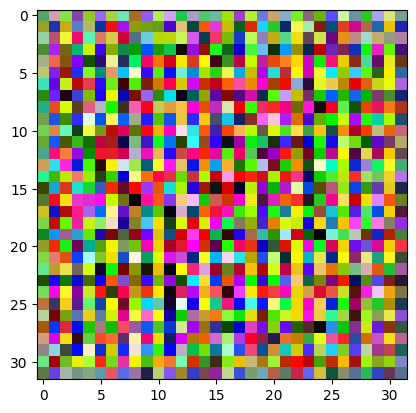

In [14]:
import matplotlib.pyplot as plt

# Rescale from [-1, 1] to [0, 1] for plotting
img_display = result_image.squeeze().permute(1, 2, 0).numpy()
img_display = (img_display + 1) / 2

plt.imshow(img_display)
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

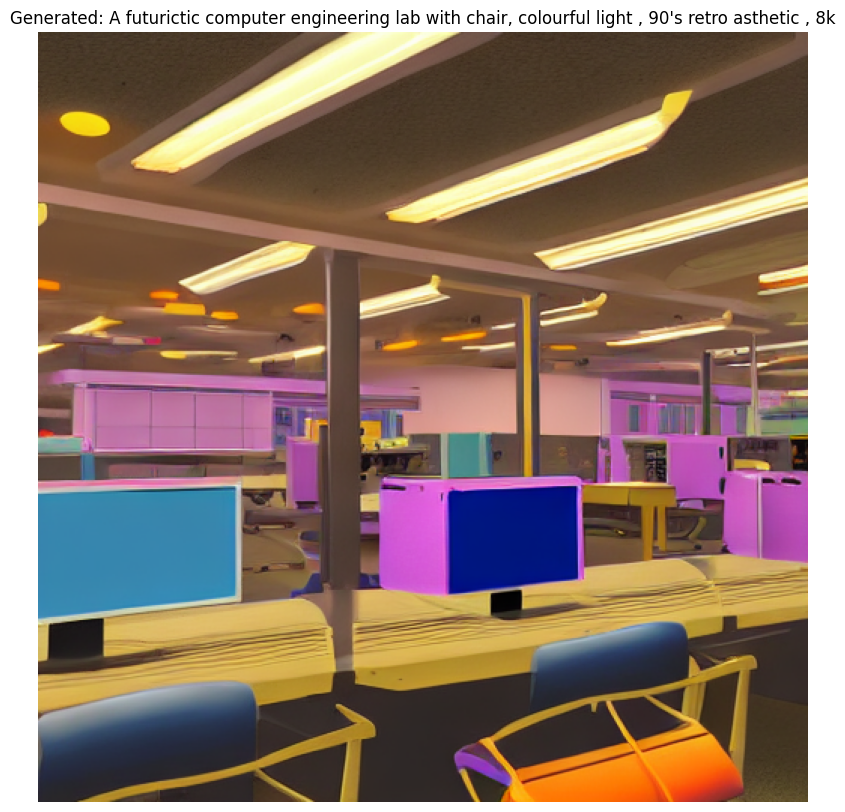

In [18]:
prompt ="A futurictic computer engineering lab with chair, colourful light , 90's retro asthetic , 8k"
pipeline.run(prompt)